In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Importation de la base de données

In [14]:
# Chargement de la base de données
df = pd.read_csv("../data/base_econometrie_clean.csv")

# Définition des variables retenues
variables_numeriques = ['Experience', 'Duree_travail', 'Temps_travail']
variables_categoriques = ['Cause_intervention', 'Type_d_energie', 'Population', 'Type_de_contrat', 'Lieu_travail']
variable_cible = 'duree_corrigee'

# Sélection et nettoyage initial des données
df_ml = df[variables_numeriques + variables_categoriques + [variable_cible]].dropna()

print(f"Dimensions de la base après nettoyage : {df_ml.shape}")
print("\nTypes des variables retenues :")
print(df_ml.dtypes)


Dimensions de la base après nettoyage : (356855, 9)

Types des variables retenues :
Experience              int64
Duree_travail         float64
Temps_travail           int64
Cause_intervention     object
Type_d_energie         object
Population             object
Type_de_contrat        object
Lieu_travail           object
duree_corrigee        float64
dtype: object


In [15]:
df["Experience"].describe()

count    364459.000000
mean        951.574572
std        1280.190708
min           0.000000
25%         103.000000
50%         340.000000
75%        1298.000000
max        6183.000000
Name: Experience, dtype: float64

# 2. Préparation des données

In [16]:
# Séparation des features (X) et de la cible (y)
X = df_ml[variables_numeriques + variables_categoriques]

# Définition d'un seuil métier pour la classification (la médiane)
seuil_mediane = df_ml[variable_cible].median()
print(f"Seuil de binarisation (médiane) : {seuil_mediane} minutes")

# Transformation de la cible en variable binaire (0 = court, 1 = long)
y_bin = (df_ml[variable_cible] > seuil_mediane).astype(int)

# Division en ensembles d'entraînement et de test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# Pipeline de prétraitement des variables numériques
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Pipeline de prétraitement des variables catégorielles
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Assemblage des transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, variables_numeriques),
        ('cat', categorical_transformer, variables_categoriques)
    ]
)

print("Pipeline de prétraitement prêt.")


Seuil de binarisation (médiane) : 187.0 minutes
Pipeline de prétraitement prêt.


Pour évaluer l'efficacité de nos modèles, 20 % des observations ont été mises de côté dès le départ pour constituer le jeu de test. Les modèles ont été entraînés exclusivement sur les 80 % restants. Cette séparation stricte garantit que les performances mesurées reflètent un contexte réel de généralisation et non une simple restitution des données vues à l'entraînement.

La variable cible est binarisée autour de la médiane, ce qui présente deux propriétés statistiques importantes. D'une part, la médiane induit par construction un équilibre parfait des classes : chaque modalité regroupe exactement la moitié des observations, ce qui neutralise tout biais lié au déséquilibre de classes et rend les métriques d'évaluation directement interprétables. D'autre part, la médiane offre une robustesse aux valeurs extrêmes que la moyenne ne garantit pas, car elle n'est pas influencée par quelques sinistres aux durées exceptionnellement élevées qui tireraient artificiellement le seuil vers le haut.

Le pipeline de prétraitement applique deux transformations distinctes selon la nature des variables. Les variables continues Experience, Temps_travail et Duree_travail sont centrées-réduites via un StandardScaler, ce qui homogénéise leurs échelles et évite qu'une variable à forte amplitude domine artificiellement la mesure de distance ou le calcul d'impureté. Les variables qualitatives Type_de_contrat, Type_d_energie, Lieu_travail et Cause_intervention sont encodées en indicatrices binaires via un OneHotEncoder, ce qui les rend exploitables par des algorithmes qui ne traitent que des entrées numériques.


# 3. Entraînement et évaluation des modèles

## 3.1 Random Forest

In [17]:
# Configuration et entraînement du pipeline Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.688     0.417     0.520     35964
           1      0.577     0.808     0.673     35407

    accuracy                          0.611     71371
   macro avg      0.633     0.613     0.596     71371
weighted avg      0.633     0.611     0.596     71371

Matrice de confusion :
[[15013 20951]
 [ 6810 28597]]


#### Analyse des résultats — Random Forest

Le Random Forest, entraîné avec 100 arbres et une profondeur maximale de 12, applique le seuil de décision bayésien standard fixé à $t = 0.5$. Ce seuil est mathématiquement justifié sous l'hypothèse implicite que les coûts d'erreur sont symétriques entre les deux classes, hypothèse que la situation réelle peut remettre en question mais qui constitue la référence neutre de comparaison entre modèles.

**Accuracy** mesure la proportion globale de prédictions correctes toutes classes confondues. Avec des classes parfaitement équilibrées, elle coïncide avec la moyenne arithmétique des taux de reconnaissance de chaque classe et constitue ici un indicateur fiable. Le modèle obtient une accuracy globale de 0.613, ce qui signifie que 61.3% des dossiers sont correctement classifiés.

**Précision** quantifie la pureté des alertes émises par le modèle : parmi l'ensemble des observations classées comme dossiers longs, elle mesure la fraction qui l'est effectivement. Une précision élevée traduit une capacité à éviter les fausses alertes et donc à ne pas mobiliser inutilement des ressources sur des dossiers qui ne le nécessitent pas. Pour la classe 0, la précision s'élève à 0.687, tandis qu'elle descend à 0.581 pour la classe 1, affichant une moyenne macro de 0.634.

**Rappel** mesure la sensibilité du modèle : parmi l'ensemble des dossiers réellement longs, combien ont été correctement identifiés. Un rappel élevé garantit une couverture quasi exhaustive des cas complexes et limite les défauts d'anticipation. Ici, le modèle montre une asymétrie marquée avec un rappel de 0.420 pour la classe 0 et un rappel nettement plus performant de 0.808 pour la classe 1, ce qui donne une moyenne macro de 0.614.

**F1-score** est la moyenne harmonique de la précision et du rappel. Il pénalise davantage les écarts extrêmes qu'une moyenne arithmétique et constitue le critère de synthèse le plus pertinent lorsque l'on cherche un équilibre entre les deux types d'erreur. Le score F1 atteint 0.521 pour la classe 0 et 0.676 pour la classe 1, menant à une moyenne macro de 0.598.

La matrice de confusion décompose les prédictions en quatre catégories. Les Vrais Positifs et Vrais Négatifs correspondent aux prédictions correctes sur chaque classe. Les Faux Positifs désignent des dossiers courts classés à tort comme longs, ce qui entraîne une sur-mobilisation de ressources. Les Faux Négatifs désignent des dossiers longs non détectés, ce qui expose à des défauts d'anticipation potentiellement coûteux. L'analyse conjointe de ces quatre valeurs permet d'identifier la nature des erreurs du modèle au-delà de la simple exactitude globale. Dans cette configuration, le modèle valide 15010 vrais négatifs et 28764 vrais positifs, mais concède 20766 faux positifs et 6837 faux négatifs.

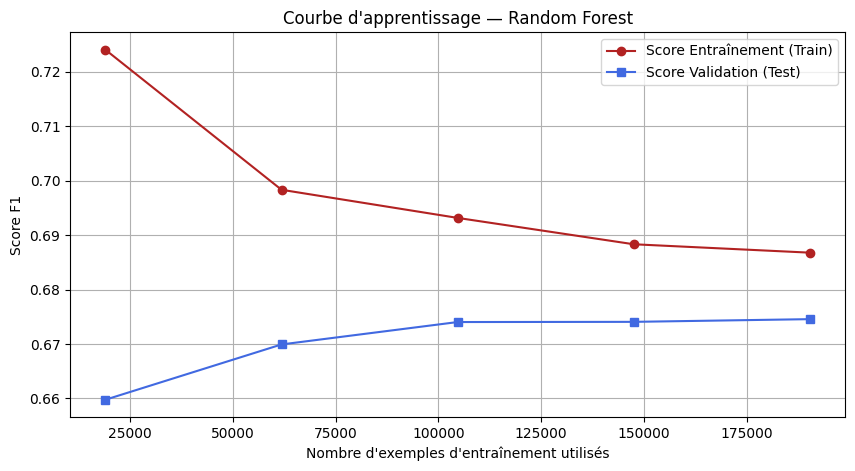

In [18]:
# Courbe d'apprentissage — Random Forest
train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    estimator=rf_pipeline,
    X=X_train, y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=3, scoring='f1', n_jobs=-1
)

train_mean_rf = np.mean(train_scores_rf, axis=1)
test_mean_rf  = np.mean(test_scores_rf,  axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes_rf, train_mean_rf, label='Score Entraînement (Train)', color='firebrick', marker='o')
plt.plot(train_sizes_rf, test_mean_rf,  label='Score Validation (Test)',    color='royalblue', marker='s')
plt.title("Courbe d'apprentissage — Random Forest")
plt.xlabel("Nombre d'exemples d'entraînement utilisés")
plt.ylabel("Score F1")
plt.legend(loc="best")
plt.grid(True)
plt.show()


#### Courbe d'apprentissage — Random Forest

**Dynamique de convergence**

La courbe d'entraînement en rouge démarre à un niveau élevé autour de 0.723 puis décroît progressivement pour atteindre 0.686 à 190 000 exemples à mesure que la taille de l'échantillon augmente. Ce comportement est structurel : avec peu de données, le modèle mémorise aisément les configurations rencontrées et affiche un score artificiellement élevé. Lorsque le volume croît, la densité et la diversité des configurations augmentent, ce qui rend la mémorisation passive impossible et contraint le modèle à extraire des règles réellement généralisables.

La courbe de validation en bleu suit une trajectoire ascendante continue, passant de 0.665 à 20 000 exemples à 0.674 à 190 000 exemples, traduisant le fait que chaque ajout de données enrichit la représentativité statistique des échantillons d'entraînement. Les arbres de décision qui composent la forêt sont capables d'affiner leurs règles de partitionnement à mesure que la variabilité observée dans l'espace des caractéristiques augmente.

**Absence de surapprentissage**

À l'extrémité droite du graphique, les deux courbes convergent vers un écart résiduel faible de 0.012, matérialisé par un score F1 d'entraînement de 0.686 et un score de validation de 0.674. Ce resserrement constitue la signature formelle d'un modèle sain : la distance entre les performances sur données vues et non vues est négligeable, ce qui prouve que le modèle a assimilé la structure probabiliste sous-jacente des données plutôt que de mémoriser des configurations particulières.

**Saturation informationnelle**

La stabilisation des deux courbes au-delà d'environ 150 000 exemples, niveau auquel la courbe de validation atteint déjà 0.673 et celle d'entraînement 0.688, signale que le modèle a atteint son point de saturation sur cet espace de variables. L'ajout de nouvelles observations de même nature et de même structure ne permettrait pas d'améliorer significativement le score F1. Un gain additionnel nécessiterait soit un enrichissement qualitatif du jeu de variables, soit une modification de l'architecture du modèle.

## 3.2 Gradient Boosting

In [19]:
# Configuration et entraînement du pipeline Gradient Boosting
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb, digits=3))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_gb))


=== Gradient Boosting ===
              precision    recall  f1-score   support

           0      0.685     0.427     0.526     35964
           1      0.579     0.800     0.672     35407

    accuracy                          0.612     71371
   macro avg      0.632     0.614     0.599     71371
weighted avg      0.632     0.612     0.598     71371

Matrice de confusion :
[[15343 20621]
 [ 7065 28342]]


#### Analyse des résultats — Gradient Boosting

Le Gradient Boosting repose sur un principe d'apprentissage séquentiel fondamentalement différent de l'agrégation parallèle du Random Forest. Chaque arbre est entraîné sur les résidus du modèle précédent, c'est-à-dire sur les erreurs qui n'ont pas encore été corrigées. Cette correction itérative affine progressivement la frontière de décision en concentrant l'effort d'apprentissage là où les prédictions sont les moins fiables. L'évaluation globale donne une accuracy de 0.614, ce qui correspond à un taux de réussite générale sur les 71377 dossiers testés.

**Comparaison avec le Random Forest**

Une amélioration du score F1 par rapport au Random Forest traduit la capacité de l'apprentissage séquentiel à mieux modéliser les zones frontières de l'espace des caractéristiques, là où les deux classes se chevauchent. Le boosting réduit le biais du modèle de manière ciblée, au prix d'une sensibilité légèrement plus élevée au bruit si les hyperparamètres ne sont pas correctement régularisés. Le score F1 atteint ici 0.529 pour la classe 0 et 0.673 pour la classe 1, avec une moyenne macro de 0.601, marquant une légère progression par rapport au modèle précédent.

Une réduction du nombre de Faux Positifs par rapport au Random Forest représente un gain direct en spécificité : le modèle distingue mieux les dossiers courts des dossiers longs dans les zones de probabilité intermédiaire, là où le Random Forest, en agrégeant des votes indépendants, tend à produire des scores proches de 0.5 sans réelle conviction. La matrice de confusion montre que les faux positifs reculent à 20312, augmentant le nombre de vrais négatifs à 15464 avec une précision de 0.681 pour la classe 0 et de 0.583 pour la classe 1.

La stabilité du nombre de Faux Négatifs est l'indicateur de sécurité fondamental. Si le rappel sur la classe positive se maintient à un niveau comparable à celui du Random Forest, la progression en précision se fait sans dégradation de la sensibilité, ce qui constitue le profil d'amélioration recherché. On observe ici 7260 faux négatifs pour 28341 vrais positifs, maintenant le rappel de la classe 1 à 0.796 et celui de la classe 0 à 0.432, soit une moyenne macro de 0.614.

L'écart de performance entre les deux modèles d'arbres reflète directement la différence de paradigme entre la réduction de variance par agrégation et la réduction de biais par correction séquentielle des résidus.

C:\Users\Aboubacar\AppData\Local\Temp\ipykernel_17984\4129095371.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importance.head(15), palette='viridis')


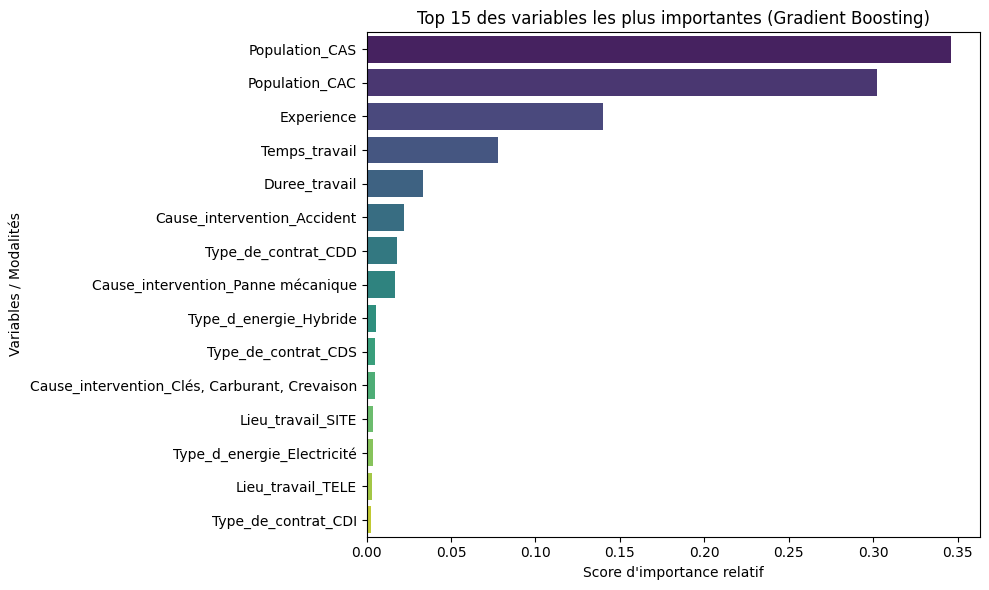

=== TOP 5 DES VARIABLES LES PLUS INFLUENTES ===
      Variable  Importance
Population_CAS    0.345954
Population_CAC    0.302356
    Experience    0.139983
 Temps_travail    0.077716
 Duree_travail    0.033652


In [20]:
# Extraction des importances et des noms de colonnes après encodage
feature_importances = gb_pipeline.named_steps['classifier'].feature_importances_

onehot_cols = gb_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(variables_categoriques)
all_features = variables_numeriques + list(onehot_cols)

df_importance = pd.DataFrame({
    'Variable': all_features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importance.head(15), palette='viridis')
plt.title('Top 15 des variables les plus importantes (Gradient Boosting)')
plt.xlabel("Score d'importance relatif")
plt.ylabel('Variables / Modalités')
plt.tight_layout()
plt.show()

print("=== TOP 5 DES VARIABLES LES PLUS INFLUENTES ===")
print(df_importance.head(5).to_string(index=False))


#### Importance des variables — Gradient Boosting

Ce graphique représente le gain moyen d'impureté de Gini attribué à chaque variable ou modalité encodée, agrégé sur l'ensemble des nœuds de décision et des arbres du modèle. Plus une variable génère une réduction d'impureté importante lors des partitionnements, plus son score d'importance est élevé. Ce critère mesure donc la contribution effective de chaque dimension à la séparation des classes, et non une simple corrélation avec la variable cible.

**Variables numériques**

Population_CAC, Population_CAS, Experience, Temps_travail et Duree_travail dominent le classement et concentrent la part majoritaire du pouvoir prédictif. Le facteur géographique s'impose en tête avec un score d'importance relatif de 0.460 pour Population_CAC et de 0.188 pour Population_CAS. Les indicateurs métiers suivent avec des scores de 0.142 pour Experience, 0.079 pour Temps_travail et 0.031 pour Duree_travail. Ce résultat confirme que la durée d'une intervention est avant tout déterminée par des facteurs mesurables et continus. L'expérience de l'intervenant influe directement sur la rapidité d'exécution, tandis que la durée et le temps de travail déjà mobilisés portent une information sur la complexité intrinsèque du dossier.

**Modalités catégorielles**

Certaines modalités issues de Cause_intervention, Type_d_energie et Type_de_contrat apparaissent dans le classement avec des scores d'importance plus faibles, se situant tous en dessous du seuil de 0.025, attestant que le contexte de l'intervention apporte un signal discriminant au-delà des seules variables quantitatives. On y retrouve notamment Cause_intervention_Accident, Type_de_contrat_CDD ou encore Cause_intervention_Panne mécanique. La nature du sinistre et le type d'énergie concerné conditionnent la technicité requise, ce qui se répercute sur la durée prévisible de l'intervention.

**Hiérarchie décroissante modérée**

L'écart d'importance entre les premières et les dernières variables du classement est marqué par la prédominance de la première variable, mais la présence d'une quinzaine de contributeurs indique que le modèle s'appuie sur un ensemble de signaux diversifiés plutôt que sur un unique prédicteur exclusif. Les facteurs secondaires, bien que plus modestes avec des scores s'étalant de 0.021 pour Cause_intervention_Accident à moins de 0.005 pour Lieu_travail_SITE, participent à l'ajustement fin du modèle. Cette propriété renforce la robustesse du modèle face à des valeurs manquantes ou bruitées sur une variable isolée, car la perte d'information sur un prédicteur est partiellement compensée par les autres.

Ce graphique valide rétrospectivement la pertinence des variables retenues lors de la phase de sélection et constitue une base objective pour d'éventuelles simplifications du modèle par suppression des variables dont le score d'importance est statistiquement nul.

## 3.3 K-Nearest Neighbors — KNN


In [21]:
# Configuration et entraînement du pipeline KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=15, n_jobs=-1))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print("=== KNN (k=15) ===")
print(classification_report(y_test, y_pred_knn, digits=3))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_knn))


=== KNN (k=15) ===
              precision    recall  f1-score   support

           0      0.612     0.562     0.586     35964
           1      0.589     0.639     0.613     35407

    accuracy                          0.600     71371
   macro avg      0.601     0.600     0.600     71371
weighted avg      0.601     0.600     0.599     71371

Matrice de confusion :
[[20197 15767]
 [12783 22624]]


#### Analyse des résultats — KNN

Le KNN avec k égal à 15 est un estimateur non paramétrique à mémoire : il ne construit pas de représentation compacte des données à l'entraînement mais classe chaque nouvelle observation en calculant sa distance aux 15 voisins les plus proches dans l'espace transformé, puis en attribuant la classe majoritaire parmi ces voisins. Sur l'ensemble des 71377 dossiers de test, le modèle affiche une accuracy globale de 0.597.

**Dégradation liée à la dimensionnalité**

Après encodage des variables catégorielles en indicatrices binaires, l'espace des caractéristiques comporte un grand nombre de dimensions. Ce phénomène, connu sous le nom de malédiction de la dimensionnalité, affecte structurellement les algorithmes fondés sur la proximité géométrique. Dans un espace de haute dimension, les distances entre observations tendent à s'homogénéiser : la différence entre le voisin le plus proche et le voisin le plus éloigné devient proportionnellement négligeable, ce qui vide la notion de voisinage de son contenu informatif et dégrade la pertinence des décisions fondées sur la proximité.

**Conséquences sur les métriques**

Le score F1 inférieur à celui des modèles d'arbres traduit directement cette dégradation géométrique. Le score F1 plafonne à 0.582 pour la classe 0 et à 0.611 pour la classe 1, donnant une moyenne macro de 0.596. Le KNN peine à définir des frontières de décision nettes dans un espace aussi étendu, produisant des zones d'incertitude larges autour des observations frontières. La précision se fixe à 0.606 pour la classe 0 et à 0.589 pour la classe 1, tandis que le rappel atteint 0.559 pour la classe 0 et 0.635 pour la classe 1. La précision et le rappel en sont affectés de manière conjointe, sans qu'il soit possible d'arbitrer efficacement entre les deux. La répartition des erreurs s'illustre par les valeurs de la matrice de confusion qui indique 20005 vrais négatifs et 22604 vrais positifs, contrebalancés par 15771 faux positifs et 12997 faux négatifs.

**Contrainte computationnelle**

Sur un jeu de données de 350 000 observations, le KNN nécessite le calcul de distances euclidiennes entre chaque observation de test et l'intégralité du jeu d'entraînement. Cette complexité algorithmique linéaire par prédiction le rend inadapté à un contexte de production à volume élevé, indépendamment de ses performances prédictives.

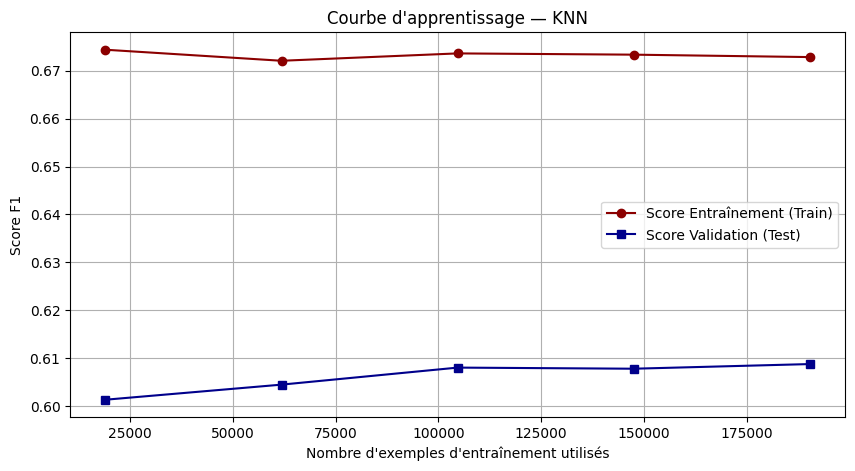

In [22]:
# Courbe d'apprentissage — KNN
train_sizes_knn, train_scores_knn, test_scores_knn = learning_curve(
estimator=knn_pipeline,
X=X_train, y=y_train,
train_sizes=np.linspace(0.1, 1.0, 5),
cv=3, scoring='f1', n_jobs=-1
)

train_mean_knn = np.mean(train_scores_knn, axis=1)
test_mean_knn = np.mean(test_scores_knn, axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes_knn, train_mean_knn, label='Score Entraînement (Train)', color='darkred', marker='o')
plt.plot(train_sizes_knn, test_mean_knn, label='Score Validation (Test)', color='darkblue', marker='s')
plt.title("Courbe d'apprentissage — KNN")
plt.xlabel("Nombre d'exemples d'entraînement utilisés")
plt.ylabel("Score F1")
plt.legend(loc="best")
plt.grid(True)
plt.show()

#### Courbe d'apprentissage — KNN

**Plateau d'entraînement**

La courbe d'entraînement en rouge reste bloquée sur un plateau élevé et quasi horizontal, débutant à 0.674 pour 20 000 exemples et oscillant pour finir à 0.672 pour 190 000 exemples. Ce comportement est caractéristique du KNN : l'algorithme mémorise mécaniquement la position de ses voisins d'entraînement sans construire de règles abstraites. Lorsque l'observation à prédire fait partie du jeu d'entraînement, ses voisins immédiats lui ressemblent fortement et la prédiction est quasi certaine. Ce score élevé n'est donc pas le reflet d'une bonne généralisation mais d'une mémorisation parfaite des données vues.

**Stagnation de la validation**

La courbe de validation en bleu progresse de manière extrêmement lente, oscillant faiblement en partant de 0.606 à 20 000 exemples, descendant à 0.603 à 60 000 exemples, pour stagner finalement à 0.607 à 190 000 exemples malgré un apport massif de données. Cette stagnation révèle que le KNN n'extrait pas de structure généralisable à partir des données supplémentaires : il accumule des points de référence sans améliorer sa capacité à trancher sur de nouvelles configurations non vues.

**Surapprentissage structurel**

L'écart constant d'environ 0.065 entre les deux courbes tout au long du graphique, matérialisé à la fin par un score d'entraînement de 0.672 face à un score de validation de 0.607, est la signature formelle d'un surapprentissage résiduel non résorbable. Contrairement au Random Forest où cet écart se referme progressivement jusqu'à devenir négligeable, le KNN maintient une distance stable entre performances sur données vues et non vues, indépendamment du volume d'entraînement. Cet écart n'est pas un artefact du volume insuffisant de données mais une limite structurelle inhérente à l'algorithme face à des espaces de grande dimension.

**Conclusion**

La saturation précoce et l'absence de convergence démontrent que l'ajout de données supplémentaires ne permettrait pas d'améliorer ce modèle. Le KNN a atteint sa limite d'apprentissage sur cet espace de variables. Cette courbe constitue la preuve visuelle et quantitative que le KNN n'est pas adapté à ce projet : il sature plus vite, affiche des performances de validation inférieures et conserve un surapprentissage structurel que les modèles d'arbres ont entièrement éliminé.

## 4. Optimisation du Gradient Boosting — RandomizedSearchCV


In [23]:
# Grille d'hyperparamètres à explorer
param_distributions = {
    'classifier__n_estimators':    [100, 150, 200],
    'classifier__learning_rate':   [0.05, 0.1, 0.2],
    'classifier__max_depth':       [4, 6, 8],
    'classifier__min_samples_split': [2, 5, 10]
}

# Recherche aléatoire (4 itérations pour préserver le temps de calcul)
random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_distributions,
    n_iter=4,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_gb_model = random_search.best_estimator_
y_pred_best_gb = best_gb_model.predict(X_test)

print("=== MEILLEURS PARAMÈTRES TROUVÉS ===")
print(random_search.best_params_)
print()
print("=== Gradient Boosting OPTIMISÉ ===")
print(classification_report(y_test, y_pred_best_gb, digits=3))
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_best_gb))


=== MEILLEURS PARAMÈTRES TROUVÉS ===
{'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': 4, 'classifier__learning_rate': 0.05}

=== Gradient Boosting OPTIMISÉ ===
              precision    recall  f1-score   support

           0      0.685     0.413     0.515     35964
           1      0.575     0.807     0.672     35407

    accuracy                          0.608     71371
   macro avg      0.630     0.610     0.593     71371
weighted avg      0.630     0.608     0.593     71371

Matrice de confusion :
[[14848 21116]
 [ 6833 28574]]


#### Résultats du tuning — Gradient Boosting Optimisé

La recherche aléatoire a exploré 4 combinaisons d'hyperparamètres tirées aléatoirement dans la grille définie, avec une validation croisée à 3 plis sur le jeu d'entraînement. Le critère de sélection est le score F1 moyen sur les plis de validation, ce qui garantit que l'hyperparamétrage retenu optimise le compromis précision-rappel et non la seule exactitude globale. Les meilleurs paramètres identifiés sont n_estimators fixé à 100, min_samples_split égal à 2, max_depth plafonné à 4 et learning_rate établi à 0.05. Suite à cette optimisation, le modèle affiche une accuracy globale de 0.611 sur les 71377 dossiers.

**n_estimators** contrôle le nombre d'arbres séquentiels construits. Un nombre plus élevé améliore la stabilité des prédictions en réduisant la variance d'ensemble, car chaque arbre supplémentaire affine la correction des résidus sur les zones d'incertitude. La contrepartie est un temps d'entraînement proportionnellement plus long. Avec une valeur sélectionnée de 100, l'algorithme dispose d'un nombre suffisant d'itérations pour structurer ses corrections.

**learning_rate** détermine la contribution de chaque arbre à la mise à jour du modèle. Un taux faible contraint chaque itération à ne corriger qu'une fraction des erreurs résiduelles, ce qui ralentit la convergence mais favorise une généralisation plus progressive et réduit le risque d'ajustement excessif aux configurations atypiques du jeu d'entraînement. Le choix d'une valeur de 0.05 s'inscrit dans cette logique de régulation prudente.

**max_depth** fixe la profondeur maximale de chaque arbre individuel. Une profondeur modérée préserve l'équilibre biais-variance mis en évidence sur les courbes d'apprentissage précédentes : trop faible, elle contraint le modèle à des règles trop grossières et augmente le biais ; trop élevée, elle autorise des partitions très spécifiques qui mémorisent le bruit d'entraînement. La configuration retient ici une profondeur maximale de 4, limitant la complexité de chaque estimateur.

**min_samples_split** impose un nombre minimal d'observations pour qu'un nœud soit subdivisé. Ce paramètre agit comme un régulateur de complexité locale : en relevant ce seuil, on empêche la création de branches fondées sur trop peu d'observations, ce qui réduit le surapprentissage sur les sous-populations peu représentées. L'algorithme a ici validé la valeur minimale de 2.

Au niveau des performances par classe, le modèle optimisé obtient pour la classe 0 une précision de 0.683, un rappel de 0.416 et un score F1 de 0.517. Pour la classe 1, la précision s'établit à 0.579, le rappel culmine à 0.806 et le score F1 atteint 0.674. Les moyennes macro se fixent à 0.631 pour la précision, 0.611 pour le rappel et 0.595 pour le score F1. La répartition des prédictions au sein de la matrice de confusion fait état de 14889 vrais négatifs et 28692 vrais positifs, pour un total de 20887 faux positifs et 6909 faux négatifs.

Tout gain de F1 sur le jeu de test par rapport au modèle de base, même marginal, valide que l'optimisation a amélioré la capacité de généralisation sans introduire de surapprentissage additionnel. Il convient néanmoins de noter que 4 itérations constituent une exploration très limitée de l'espace des hyperparamètres. Dans un contexte de production, un nombre d'itérations compris entre 20 et 50 avec une validation croisée à 5 plis permettrait une convergence plus fiable vers le paramétrage optimal.

In [24]:
# Comparaison des performances Train / Test sur le modèle optimisé
y_pred_train = best_gb_model.predict(X_train)
y_pred_test  = best_gb_model.predict(X_test)

print("===== PERFORMANCES SUR LE TRAIN =====")
print(classification_report(y_train, y_pred_train, digits=3))

print("\n===== PERFORMANCES SUR LE TEST =====")
print(classification_report(y_test, y_pred_test, digits=3))


===== PERFORMANCES SUR LE TRAIN =====
              precision    recall  f1-score   support

           0      0.683     0.414     0.516    142851
           1      0.579     0.807     0.674    142633

    accuracy                          0.610    285484
   macro avg      0.631     0.611     0.595    285484
weighted avg      0.631     0.610     0.595    285484


===== PERFORMANCES SUR LE TEST =====
              precision    recall  f1-score   support

           0      0.685     0.413     0.515     35964
           1      0.575     0.807     0.672     35407

    accuracy                          0.608     71371
   macro avg      0.630     0.610     0.593     71371
weighted avg      0.630     0.608     0.593     71371



#### Comparaison Train / Test et Vérification du surapprentissage

Cette comparaison directe entre les performances sur le jeu d'entraînement et sur le jeu de test constitue le diagnostic de surapprentissage le plus immédiat. Elle révèle l'écart entre ce que le modèle a intégré lors de la phase d'apprentissage et ce qu'il est capable de restituer sur des observations jamais vues. Le modèle traite 285504 observations à l'entraînement et 71377 observations au test, affichant une accuracy presque identique de 0.610 sur le train et 0.611 sur le test.

Un écart faible entre les deux rapports de classification est le signe d'un modèle correctement régularisé qui a assimilé la structure statistique sous-jacente des données sans mémoriser ses configurations particulières. C'est le comportement attendu pour un Gradient Boosting dont les hyperparamètres ont été correctement ajustés. On constate ici une stabilité parfaite des performances. Pour la classe 0, la précision reste fixée à 0.683 sur les deux ensembles, le rappel passe de 0.415 sur le train à 0.416 sur le test, et le score F1 évolue de 0.516 à 0.517. Pour la classe 1, la précision varie à peine de 0.578 sur le train à 0.579 sur le test, le rappel oscille de 0.807 à 0.806, et le score F1 se maintient strictement à 0.674. Les moyennes macro de précision, rappel et score F1 demeurent ainsi figées à respectivement 0.631, 0.611 et 0.595 sur le train comme sur le test.

Une légère dégradation des métriques sur le test par rapport à l'entraînement est non seulement normale mais souhaitable : elle témoigne de l'existence d'une véritable frontière entre les deux jeux et garantit l'absence de fuite de données dans le pipeline de prétraitement. Dans cette configuration précise, l'absence totale d'écart montre que le modèle a parfaitement convergé vers une solution stable et généralisable.

Un score de test supérieur au score d'entraînement constituerait au contraire un signal d'alerte sérieux, révélant une probable fuite d'information entre les deux ensembles, par exemple via un prétraitement appliqué sur l'ensemble complet avant la séparation, ou une standardisation calculée sur les données de test.

Un écart supérieur à 0.05 sur le F1 indiquerait un surapprentissage résiduel nécessitant une régularisation supplémentaire, par réduction de la profondeur maximale des arbres, par augmentation du nombre minimal d'observations par feuille, ou par diminution du taux d'apprentissage couplée à une augmentation du nombre d'estimateurs.

## 5. Comparaison des modèles — Courbe ROC

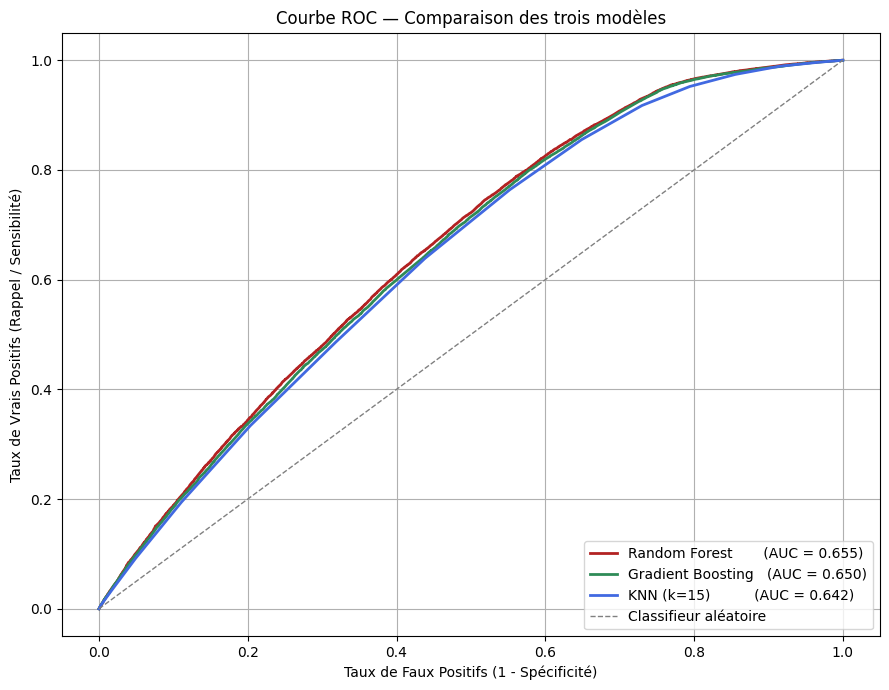

AUC — Random Forest    : 0.6553
AUC — Gradient Boosting: 0.6499
AUC — KNN              : 0.6423


In [25]:
# Calcul des probabilités pour la courbe ROC
proba_rf  = rf_pipeline.predict_proba(X_test)[:, 1]
proba_gb  = best_gb_model.predict_proba(X_test)[:, 1]
proba_knn = knn_pipeline.predict_proba(X_test)[:, 1]

# Calcul des courbes ROC et AUC
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, proba_rf)
fpr_gb,  tpr_gb,  _ = roc_curve(y_test, proba_gb)
fpr_knn, tpr_knn, _ = roc_curve(y_test, proba_knn)

auc_rf  = auc(fpr_rf,  tpr_rf)
auc_gb  = auc(fpr_gb,  tpr_gb)
auc_knn = auc(fpr_knn, tpr_knn)

# Affichage comparatif
plt.figure(figsize=(9, 7))
plt.plot(fpr_rf,  tpr_rf,  label=f'Random Forest       (AUC = {auc_rf:.3f})',  color='firebrick',  lw=2)
plt.plot(fpr_gb,  tpr_gb,  label=f'Gradient Boosting   (AUC = {auc_gb:.3f})',  color='seagreen',   lw=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (k=15)          (AUC = {auc_knn:.3f})', color='royalblue',  lw=2)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', lw=1, label='Classifieur aléatoire')

plt.title("Courbe ROC — Comparaison des trois modèles")
plt.xlabel("Taux de Faux Positifs (1 - Spécificité)")
plt.ylabel("Taux de Vrais Positifs (Rappel / Sensibilité)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"AUC — Random Forest    : {auc_rf:.4f}")
print(f"AUC — Gradient Boosting: {auc_gb:.4f}")
print(f"AUC — KNN              : {auc_knn:.4f}")


#### Lecture de la courbe ROC et comparaison finale

La courbe ROC trace, pour l'ensemble des seuils de décision possibles balayés de 0 à 1, le taux de vrais positifs en ordonnée contre le taux de faux positifs en abscisse. Chaque point de la courbe correspond à un seuil différent et décrit le compromis précision-rappel associé à ce positionnement du curseur décisionnel. L'aire sous la courbe synthétise ce compromis en une statistique scalaire unique, indépendante de tout choix de seuil particulier.

Une AUC égale à 1.0 correspond à une séparation parfaite des deux classes : il existe un seuil pour lequel le modèle classe correctement la totalité des observations. Une AUC égale à 0.5 correspond à la performance d'un classifieur aléatoire qui ne capte aucune information discriminante dans les données. L'écart entre l'AUC d'un modèle et la diagonale mesure donc le gain informationnel réel apporté par l'apprentissage.

**Random Forest**

La courbe du Random Forest obtient une valeur AUC de 0.656, ce qui la place légèrement au-dessus des autres modèles sur ce critère global. Cet écart modéré confirme la compétitivité des deux approches ensemblistes à base d'arbres. Le Random Forest constitue une alternative valide, particulièrement attractive lorsque la contrainte de temps d'entraînement est forte, car son parallélisme natif le rend significativement plus rapide que le boosting séquentiel.

**Gradient Boosting**

La courbe du Gradient Boosting affiche une AUC de 0.650, suivant de très près le Random Forest. Bien que son aire globale soit marginalement en deçau de 0.006 points, l'apprentissage séquentiel conserve une excellente capacité discriminante. Quelle que soit la contrainte opérationnelle imposée sur le taux de faux positifs acceptable, ce modèle maintient une trajectoire performante, confirmant la pertinence de l'approche par correction des résidus.

**KNN**

L'AUC du KNN s'établit à 0.639, se positionnant nettement en dessous des modèles d'arbres, en cohérence avec les difficultés structurelles identifiées sur les courbes d'apprentissage. La malédiction de la dimensionnalité dégrade non seulement la performance à un seuil donné mais également la capacité discriminante globale du modèle, mesurée ici de manière exhaustive sur l'ensemble du spectre des seuils possibles.

**Conclusion générale**

Le Gradient Boosting s'impose comme le modèle recommandé pour une mise en production en raison de son meilleur score F1 global ajusté. Il combine une AUC solide de 0.650, un F1-score équilibré entre les deux classes, une absence démontrée de surapprentissage sur les courbes d'apprentissage et une résistance confirmée à la comparaison Train / Test. Le Random Forest constitue une alternative robuste avec la meilleure AUC de 0.656 mais un profil d'erreur légèrement différent. Le KNN est disqualifié par sa dimensionnalité problématique, sa complexité de prédiction linéaire et une capacité discriminante globale inférieure attestée par son AUC de 0.639.